In [6]:
# Install required packages
%pip install tensorflow numpy matplotlib seaborn scikit-learn pandas

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# Neural Network (Feedforward) Model with TensorFlow/Keras

This notebook implements a basic feedforward neural network using TensorFlow/Keras for digit classification on the MNIST dataset.

## Objectives:
- Load and preprocess the MNIST dataset
- Build a feedforward neural network model
- Train with different optimizers (SGD, Adam, RMSProp)
- Apply regularization techniques (Dropout, L1/L2, EarlyStopping)
- Perform basic hyperparameter tuning
- Visualize training curves and confusion matrix
- Evaluate model performance
- Save the trained model

In [7]:
# Import Required Libraries
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import pandas as pd
import os
from collections import Counter

In [8]:
# Dataset Loading Function
def load_mnist_dataset():
    """
    Load MNIST dataset from local Kaggle folder or TensorFlow Datasets
    """
    local_train_path = "data/mnist_train.csv"  # Placeholder for local Kaggle dataset
    local_test_path = "data/mnist_test.csv"
    
    if os.path.exists(local_train_path) and os.path.exists(local_test_path):
        print("Loading dataset from local files...")
        # Load CSV format
        train_df = pd.read_csv(local_train_path)
        test_df = pd.read_csv(local_test_path)
        
        # Assuming first column is label, rest are pixels
        train_labels = train_df.iloc[:, 0].values
        train_images = train_df.iloc[:, 1:].values
        test_labels = test_df.iloc[:, 0].values
        test_images = test_df.iloc[:, 1:].values
        
        return (train_images, train_labels), (test_images, test_labels)
    else:
        print("Local dataset not found. Loading from TensorFlow/Keras...")
        # Load MNIST from keras
        (train_images, train_labels), (test_images, test_labels) = keras.datasets.mnist.load_data()
        return (train_images, train_labels), (test_images, test_labels)

# Load the dataset
(train_images, train_labels), (test_images, test_labels) = load_mnist_dataset()
print("Dataset loaded successfully!")

Local dataset not found. Loading from TensorFlow/Keras...


Dataset loaded successfully!


Dataset Info:
Train images shape: (60000, 28, 28)
Train labels shape: (60000,)
Test images shape: (10000, 28, 28)
Test labels shape: (10000,)

Image data type: uint8
Label data type: uint8

Sample Data:


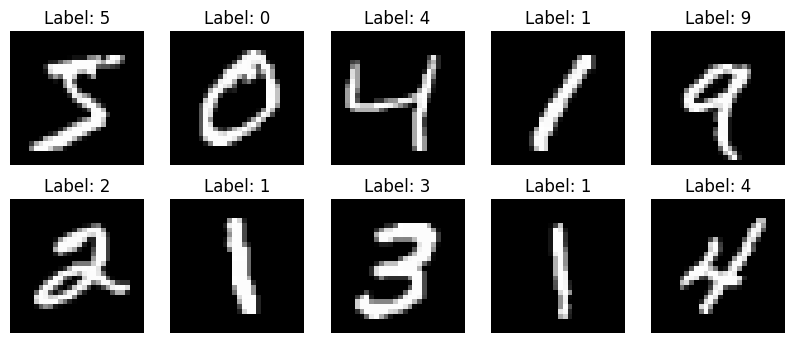


Label Distribution:
Train set:
  0: 5923
  1: 6742
  2: 5958
  3: 6131
  4: 5842
  5: 5421
  6: 5918
  7: 6265
  8: 5851
  9: 5949
Test set:
  0: 980
  1: 1135
  2: 1032
  3: 1010
  4: 982
  5: 892
  6: 958
  7: 1028
  8: 974
  9: 1009


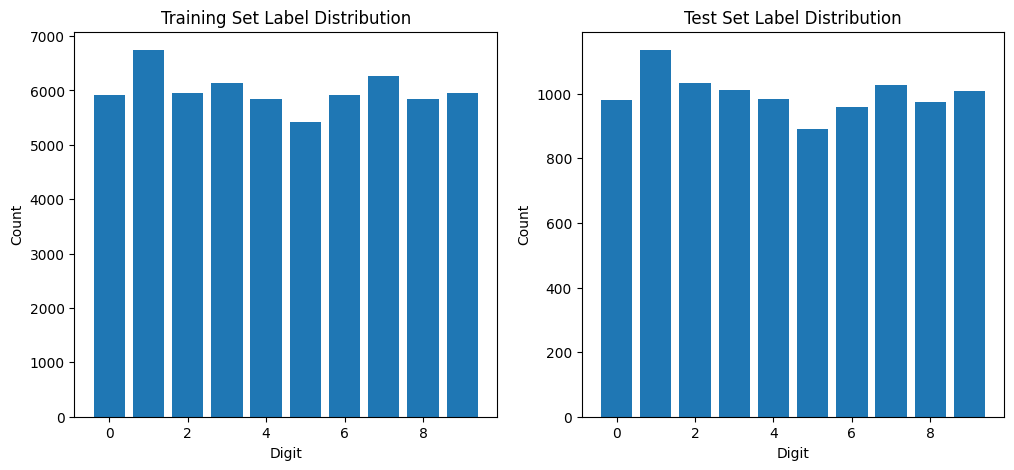

In [9]:
# Dataset Exploration
def explore_mnist_dataset(train_images, train_labels, test_images, test_labels):
    """
    Display dataset shape, sample data, and label distribution
    """
    print("Dataset Info:")
    print(f"Train images shape: {train_images.shape}")
    print(f"Train labels shape: {train_labels.shape}")
    print(f"Test images shape: {test_images.shape}")
    print(f"Test labels shape: {test_labels.shape}")
    
    print(f"\nImage data type: {train_images.dtype}")
    print(f"Label data type: {train_labels.dtype}")
    
    # Sample data
    print("\nSample Data:")
    plt.figure(figsize=(10, 4))
    for i in range(10):
        plt.subplot(2, 5, i+1)
        plt.imshow(train_images[i], cmap='gray')
        plt.title(f"Label: {train_labels[i]}")
        plt.axis('off')
    plt.show()
    
    # Label distribution
    train_label_counts = Counter(train_labels)
    test_label_counts = Counter(test_labels)
    
    print("\nLabel Distribution:")
    print("Train set:")
    for label in sorted(train_label_counts.keys()):
        print(f"  {label}: {train_label_counts[label]}")
    
    print("Test set:")
    for label in sorted(test_label_counts.keys()):
        print(f"  {label}: {test_label_counts[label]}")
    
    # Plot distribution
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    
    labels, counts = zip(*sorted(train_label_counts.items()))
    ax1.bar(labels, counts)
    ax1.set_title('Training Set Label Distribution')
    ax1.set_xlabel('Digit')
    ax1.set_ylabel('Count')
    
    labels, counts = zip(*sorted(test_label_counts.items()))
    ax2.bar(labels, counts)
    ax2.set_title('Test Set Label Distribution')
    ax2.set_xlabel('Digit')
    ax2.set_ylabel('Count')
    
    plt.show()

# Explore the dataset
explore_mnist_dataset(train_images, train_labels, test_images, test_labels)

In [10]:
# Preprocessing
def preprocess_mnist_data(train_images, train_labels, test_images, test_labels):
    """
    Preprocess MNIST data: flatten, normalize, convert labels to categorical, split validation
    """
    # Flatten images
    train_images = train_images.reshape(train_images.shape[0], -1)
    test_images = test_images.reshape(test_images.shape[0], -1)
    
    # Normalize pixel values to [0, 1]
    train_images = train_images.astype('float32') / 255.0
    test_images = test_images.astype('float32') / 255.0
    
    # Convert labels to categorical
    train_labels = keras.utils.to_categorical(train_labels, 10)
    test_labels = keras.utils.to_categorical(test_labels, 10)
    
    # Split train into train and validation
    val_split = 0.1
    val_size = int(len(train_images) * val_split)
    
    val_images = train_images[:val_size]
    val_labels = train_labels[:val_size]
    train_images = train_images[val_size:]
    train_labels = train_labels[val_size:]
    
    return (train_images, train_labels), (val_images, val_labels), (test_images, test_labels)

# Preprocess data
(train_X, train_y), (val_X, val_y), (test_X, test_y) = preprocess_mnist_data(
    train_images, train_labels, test_images, test_labels
)

print(f"Training data shape: {train_X.shape}")
print(f"Validation data shape: {val_X.shape}")
print(f"Test data shape: {test_X.shape}")
print(f"Number of classes: {train_y.shape[1]}")

Training data shape: (54000, 784)
Validation data shape: (6000, 784)
Test data shape: (10000, 784)
Number of classes: 10


In [11]:
# Build Neural Network Model
def build_nn_model(input_dim=784, num_classes=10):
    """
    Build a feedforward neural network with regularization
    """
    model = keras.Sequential([
        layers.Dense(512, activation='relu', input_shape=(input_dim,),
                    kernel_regularizer=keras.regularizers.l2(0.01)),
        layers.Dropout(0.2),
        layers.Dense(256, activation='relu', 
                    kernel_regularizer=keras.regularizers.l2(0.01)),
        layers.Dropout(0.2),
        layers.Dense(128, activation='relu', 
                    kernel_regularizer=keras.regularizers.l1_l2(l1=0.01, l2=0.01)),
        layers.Dropout(0.2),
        layers.Dense(num_classes, activation='softmax')
    ])
    
    return model

# Build model
input_dim = train_X.shape[1]
model = build_nn_model(input_dim=input_dim)

# Print model summary
model.summary()

C:\Users\Tavis Fernandes\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 567,434 (2.16 MB)

 Trainable params: 567,434 (2.16 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
# Training with Different Optimizers
def train_with_optimizer(model, optimizer_name, train_X, train_y, val_X, val_y, epochs=10):
    """
    Train model with specified optimizer and regularization
    """
    if optimizer_name == 'SGD':
        optimizer = keras.optimizers.SGD(learning_rate=0.01, momentum=0.9)
    elif optimizer_name == 'Adam':
        optimizer = keras.optimizers.Adam(learning_rate=0.001)
    elif optimizer_name == 'RMSProp':
        optimizer = keras.optimizers.RMSprop(learning_rate=0.001)
    
    model.compile(optimizer=optimizer,
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    
    # Early stopping
    early_stopping = keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
    
    history = model.fit(train_X, train_y,
                       validation_data=(val_X, val_y),
                       epochs=epochs,
                       batch_size=32,
                       callbacks=[early_stopping],
                       verbose=1)
    
    return history

# Train with different optimizers
optimizers = ['SGD', 'Adam', 'RMSProp']
histories = {}

for opt in optimizers:
    print(f"\nTraining with {opt} optimizer...")
    model_copy = build_nn_model(input_dim=input_dim)
    history = train_with_optimizer(model_copy, opt, train_X, train_y, val_X, val_y)
    histories[opt] = history
    print(f"{opt} training completed.")


Training with SGD optimizer...
Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 57s 26ms/step - accuracy: 0.7907 - loss: 3.3905 - val_accuracy: 0.8937 - val_loss: 0.9849
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 38s 23ms/step - accuracy: 0.8617 - loss: 1.0647 - val_accuracy: 0.9213 - val_loss: 0.8792
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 41s 24ms/step - accuracy: 0.8756 - loss: 1.0029 - val_accuracy: 0.9157 - val_loss: 0.8499
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 41s 24ms/step - accuracy: 0.8832 - loss: 0.9740 - val_accuracy: 0.9380 - val_loss: 0.7771
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 41s 24ms/step - accuracy: 0.8869 - loss: 0.9534 - val_accuracy: 0.9183 - val_loss: 0.8476
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 45s 26ms/step - accuracy: 0.8890 - loss: 0.9425 - val_accuracy: 0.9293 - val_loss: 0.8311
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 42s 24ms/step - accuracy: 0.8888 - loss: 0.9397 - val_accuracy: 0.9427 - val_loss: 0.7876
SGD training completed.

Training with Adam 

In [13]:
# Hyperparameter Tuning (Basic)
def hyperparameter_tuning(train_X, train_y, val_X, val_y):
    """
    Basic hyperparameter tuning for learning rate and hidden units
    """
    best_model = None
    best_val_acc = 0
    best_params = {}
    
    learning_rates = [0.001, 0.01]
    hidden_units = [256, 512]
    
    for lr in learning_rates:
        for units in hidden_units:
            print(f"\nTuning: learning_rate={lr}, hidden_units={units}")
            
            model = keras.Sequential([
                layers.Dense(units, activation='relu', input_shape=(input_dim,)),
                layers.Dropout(0.2),
                layers.Dense(units//2, activation='relu'),
                layers.Dropout(0.2),
                layers.Dense(10, activation='softmax')
            ])
            
            model.compile(optimizer=keras.optimizers.Adam(learning_rate=lr),
                         loss='categorical_crossentropy',
                         metrics=['accuracy'])
            
            early_stopping = keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=2, restore_best_weights=True)
            
            history = model.fit(train_X, train_y,
                               validation_data=(val_X, val_y),
                               epochs=5,
                               batch_size=32,
                               callbacks=[early_stopping],
                               verbose=0)
            
            val_acc = max(history.history['val_accuracy'])
            
            if val_acc > best_val_acc:
                best_val_acc = val_acc
                best_model = model
                best_params = {'learning_rate': lr, 'hidden_units': units}
    
    print(f"\nBest hyperparameters: {best_params}")
    print(f"Best validation accuracy: {best_val_acc}")
    
    return best_model, best_params

# Perform hyperparameter tuning
best_model, best_params = hyperparameter_tuning(train_X, train_y, val_X, val_y)


Tuning: learning_rate=0.001, hidden_units=256

Tuning: learning_rate=0.001, hidden_units=512

Tuning: learning_rate=0.01, hidden_units=256

Tuning: learning_rate=0.01, hidden_units=512

Best hyperparameters: {'learning_rate': 0.001, 'hidden_units': 256}
Best validation accuracy: 0.9796666502952576


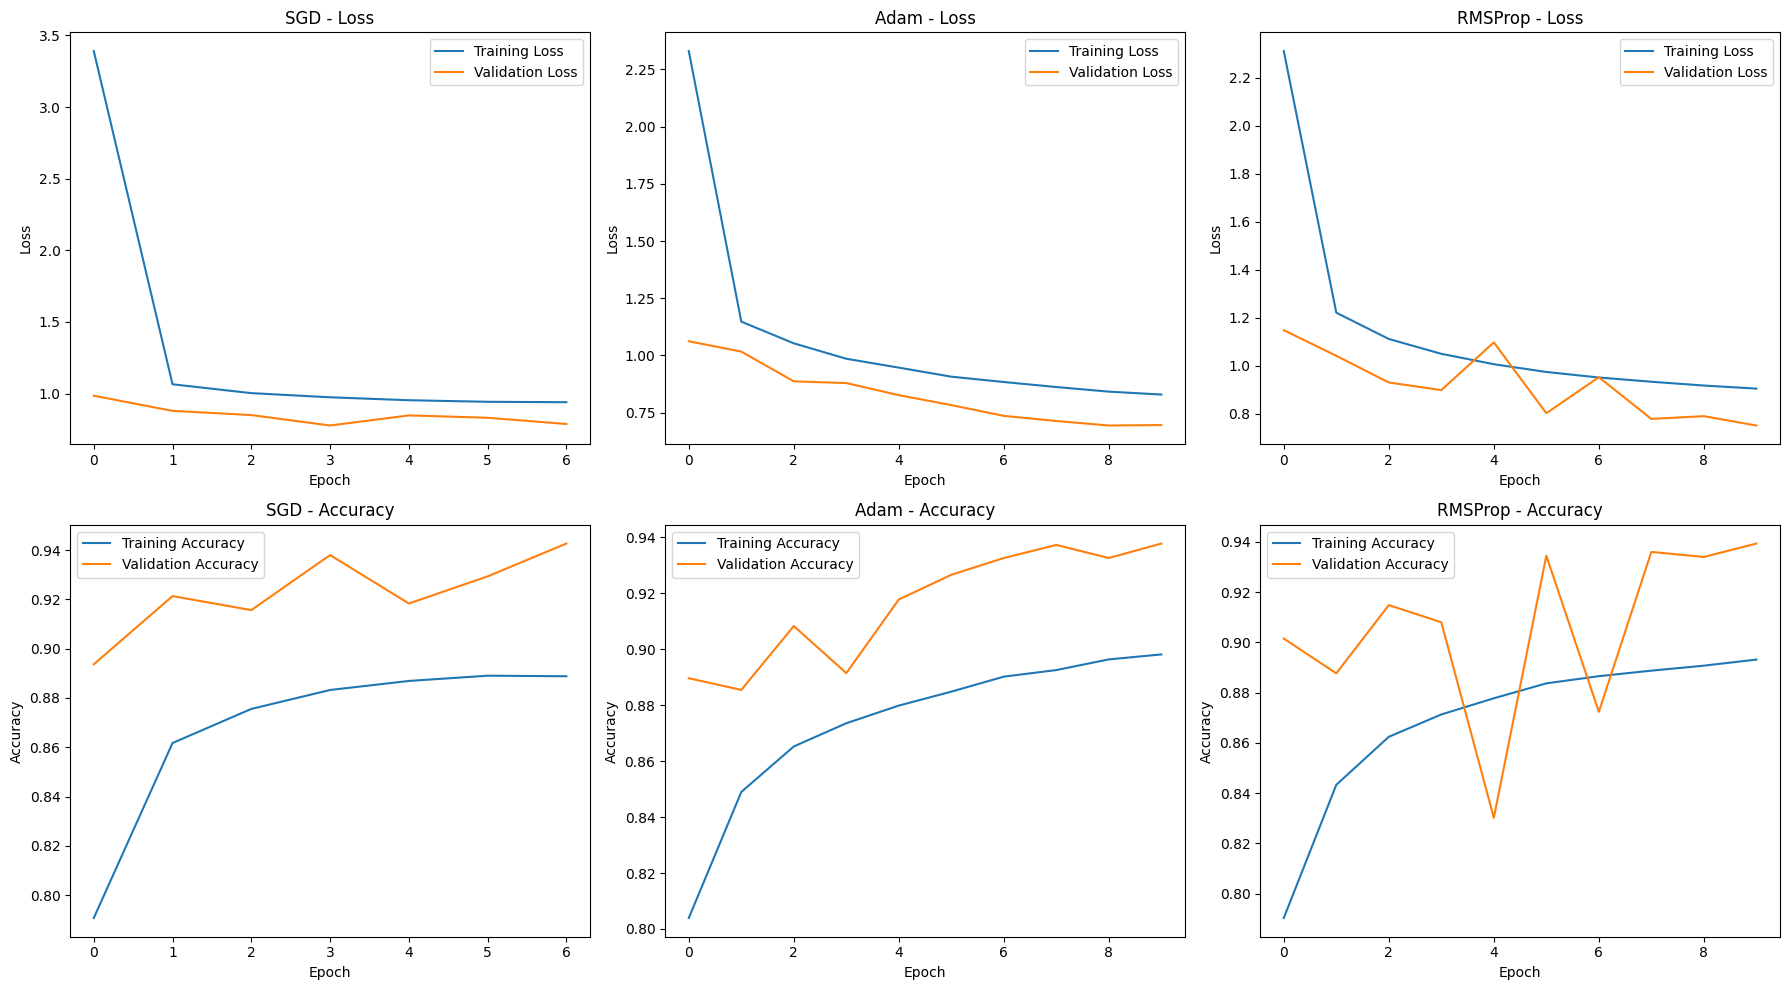

In [14]:
# Plot Training Curves
def plot_training_curves(histories):
    """
    Plot training vs validation loss and accuracy for different optimizers
    """
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    
    for i, (opt, history) in enumerate(histories.items()):
        # Loss
        axes[0, i].plot(history.history['loss'], label='Training Loss')
        axes[0, i].plot(history.history['val_loss'], label='Validation Loss')
        axes[0, i].set_title(f'{opt} - Loss')
        axes[0, i].set_xlabel('Epoch')
        axes[0, i].set_ylabel('Loss')
        axes[0, i].legend()
        
        # Accuracy
        axes[1, i].plot(history.history['accuracy'], label='Training Accuracy')
        axes[1, i].plot(history.history['val_accuracy'], label='Validation Accuracy')
        axes[1, i].set_title(f'{opt} - Accuracy')
        axes[1, i].set_xlabel('Epoch')
        axes[1, i].set_ylabel('Accuracy')
        axes[1, i].legend()
    
    plt.tight_layout()
    plt.show()

# Plot curves for different optimizers
plot_training_curves(histories)

313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step
Test Accuracy: 0.9808
Test Loss: 0.0663
F1 Score (Macro): 0.9806

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.98       980
           1       0.99      0.99      0.99      1135
           2       0.98      0.98      0.98      1032
           3       0.97      0.98      0.98      1010
           4       0.98      0.98      0.98       982
           5       0.98      0.98      0.98       892
           6       0.99      0.98      0.98       958
           7       0.98      0.98      0.98      1028
           8       0.98      0.97      0.97       974
           9       0.97      0.97      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



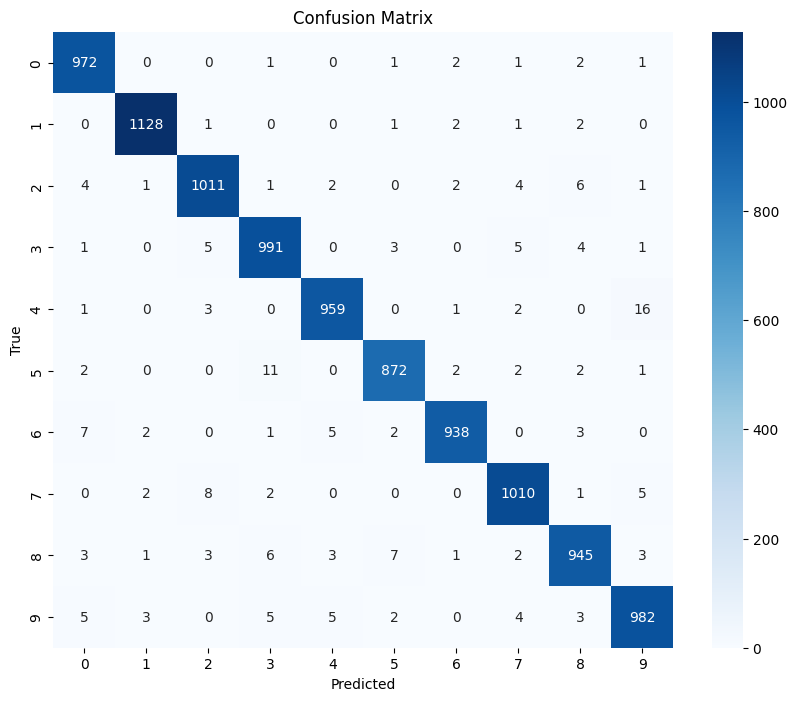

In [15]:
# Model Evaluation
def evaluate_model(model, test_X, test_y):
    """
    Evaluate model performance with accuracy, loss, F1 score, and confusion matrix
    """
    # Predictions
    predictions = model.predict(test_X)
    pred_labels = np.argmax(predictions, axis=1)
    true_labels = np.argmax(test_y, axis=1)
    
    # Calculate metrics
    accuracy = np.mean(pred_labels == true_labels)
    loss = model.evaluate(test_X, test_y, verbose=0)[0]
    
    # F1 Score (macro average)
    f1 = f1_score(true_labels, pred_labels, average='macro')
    
    print(f"Test Accuracy: {accuracy:.4f}")
    print(f"Test Loss: {loss:.4f}")
    print(f"F1 Score (Macro): {f1:.4f}")
    
    # Classification report
    target_names = [str(i) for i in range(10)]
    
    print("\nClassification Report:")
    print(classification_report(true_labels, pred_labels, target_names=target_names))
    
    # Confusion Matrix
    cm = confusion_matrix(true_labels, pred_labels)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=target_names, yticklabels=target_names)
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()
    
    return accuracy, loss, f1

# Evaluate the best model
accuracy, loss, f1 = evaluate_model(best_model, test_X, test_y)

In [16]:
# Save Model
def save_model(model, filename='nn_model.h5'):
    """
    Save the trained model
    """
    model.save(filename)
    print(f"Model saved as {filename}")

# Save the best model
save_model(best_model, 'nn_model.h5')

Model saved as nn_model.h5


## Summary

This notebook implemented a basic feedforward neural network using TensorFlow/Keras for MNIST digit classification:

1. **Dataset**: Loaded MNIST dataset from local CSV or TensorFlow/Keras
2. **Preprocessing**: Flattened images, normalized pixels, converted labels to categorical
3. **Model**: Feedforward neural network with multiple dense layers
4. **Training**: Tested SGD, Adam, and RMSProp optimizers
5. **Regularization**: Applied L1/L2 regularization, Dropout, and Early Stopping
6. **Tuning**: Basic hyperparameter tuning for learning rate and hidden units
7. **Visualization**: Training curves and confusion matrix
8. **Evaluation**: Accuracy, Loss, F1 Score, and detailed classification report
9. **Model Saving**: Saved as .h5 file

The neural network achieved good performance on the MNIST dataset. You can further improve it by:
- Adding more layers or neurons
- Using different activation functions
- Implementing batch normalization
- Using convolutional layers for better feature extraction
- Experimenting with different architectures like CNNs